In [1]:
#!pip install pytorch-model-summary

In [2]:
#!pip install pennylane

In [3]:
#!pip install pennylane-lightning

In [4]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from pytorch_model_summary import summary
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import RandomLayers
from pennylane.templates import BasisStatePreparation
from pennylane.templates import StronglyEntanglingLayers
from pennylane.templates import BasicEntanglerLayers
from sklearn.preprocessing import MinMaxScaler
np.random.seed(0)           # Seed for NumPy random number generator
torch.manual_seed(0)        # Seed for Pytorch random number generator

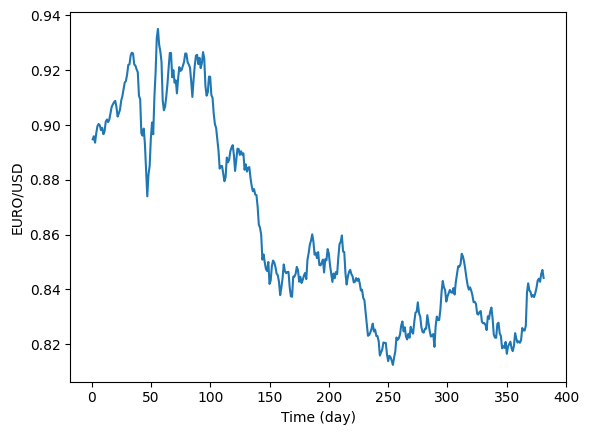

In [5]:
data_usd_euro = np.genfromtxt('USD-EURO-Time-Series.csv', delimiter=',')
# plot of USD-EURO series
plt.plot(np.arange(1,382), data_usd_euro)
plt.ylabel('EURO/USD')
plt.xlabel('Time (day)')
plt.show()

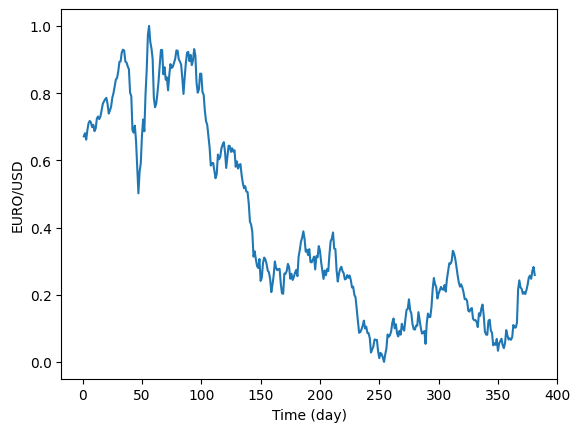

In [6]:
# define min max scaler
scaler = MinMaxScaler()
# The data is normalized is scaled in the range [0,1]
scaled_data_usd_euro = scaler.fit_transform(data_usd_euro.reshape(-1,1))
# Plot of USD-EURO
plt.plot(np.arange(1,382),scaled_data_usd_euro)
plt.ylabel('EURO/USD')
plt.xlabel('Time (day)')
plt.show()

In [7]:
# We use 376 simulation data points to build the model:
# [x(t-4),x(t-3),x(t-2),x(t-1),x(t);x(t+1)], t = 5,...,380
scaled_data = np.zeros((376,6))
for t in range(4,380):
  idx = t-4 # row index. We have 1000 rows (0-999)
  scaled_data[idx,:] = [scaled_data_usd_euro[t-4],scaled_data_usd_euro[t-3],scaled_data_usd_euro[t-2],
                        scaled_data_usd_euro[t-1],scaled_data_usd_euro[t],scaled_data_usd_euro[t+1]]
# We use the first 300 points to train the model and the rest 
# for the testing phase:
scaled_data_train = scaled_data[0:300,0:6]
scaled_data_test = scaled_data[300:,0:6]

C:\Users\52333\AppData\Local\Temp\ipykernel_11620\1452979454.py:6: DeprecationWarning: setting an array element with a sequence. This was supported in some cases where the elements are arrays with a single element. For example `np.array([1, np.array([2])], dtype=int)`. In the future this will raise the same ValueError as `np.array([1, [2]], dtype=int)`.
  scaled_data[idx,:] = [scaled_data_usd_euro[t-4],scaled_data_usd_euro[t-3],scaled_data_usd_euro[t-2],


In [8]:
# n_points = 300
X_train = scaled_data_train[:,:5]  
Y_train = scaled_data_train[:,5]
X_test = scaled_data_test[:,:5]  
Y_test = scaled_data_test[:,5]

In [9]:
# class to construct a custom dataloader: 
class CustomDataset(Dataset):
    def __init__(self, inputs, labels=None, transforms=None):
        self.X = inputs
        self.y = labels
        self.transforms = transforms
         
    def __len__(self):
        return (len(self.X))
    
    def __getitem__(self, i):
        data =  self.X[i,:]
        
        if self.transforms:
            data = self.transforms(data)
            
        if self.y is not None:
            return (data, self.y[i])
        else:
            return data

# We convert to torch tensor:
X_train = torch.from_numpy(X_train)
Y_train = torch.from_numpy(Y_train)
X_test = torch.from_numpy(X_test)
Y_test = torch.from_numpy(Y_test)

train_data = CustomDataset(X_train, Y_train)
test_data = CustomDataset(X_test, Y_test)
# Dataloaders
batch_size_train = 1
batch_size_test = 1
trainloader = DataLoader(train_data, batch_size=batch_size_train, shuffle=True)
testloader = DataLoader(test_data, batch_size=batch_size_test, shuffle=False)

In [10]:
class QuanvLayer1D(nn.Module):
    def __init__(self, sim_dev="default.qubit", out_channels = 4, kernel_size=2, stride=1, padding=1, n_layers=2, seed=1234,ansatz='basic_layers'):
        super(QuanvLayer1D, self).__init__()       
        # init device
        self.wires = out_channels # We use n qubits to obtain n out_channels
        self.dev = qml.device(sim_dev, wires=self.wires)
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.out_channels = out_channels
        self.n_layers=n_layers
        self.ansatz=ansatz
        
        if seed is None:
            seed = np.random.randint(low=0, high=10e6)
            
        print("Initializing Circuit with random seed", seed)

        def custom_ansatz(i,weights):
            for j in range(self.out_channels):
                qml.RX(weights[i+1,j], wires=j)
                if j!=self.out_channels-1:
                    seq=[j,j+1]
                else:
                    seq=[0,j]
                qml.CNOT(wires=seq)
                qml.RY(weights[i+1,j], wires=j)
                qml.CNOT(wires=seq)
                qml.RZ(weights[i+1,j], wires=j)

        def nxn_params(i,weights):
            nxn=int(self.out_channels*self.out_channels)
            for j in range(self.out_channels):
                for n in range(nxn):
                    qml.RX(weights[n,i+1,j], wires=j)
                if j!=self.out_channels-1:
                    seq=[j,j+1]
                else:
                    seq=[0,j]
                qml.CNOT(wires=seq)
                for n in range(nxn):
                    qml.RY(weights[n,i+1,j], wires=j)
                qml.CNOT(wires=seq)
                for n in range(nxn):
                    qml.RZ(weights[n,i+1,j], wires=j)
        # random circuits
        @qml.qnode(device=self.dev, interface="torch", diff_method="backprop") #  device= "default.qubit" or "lightning.qubit"
        def circuit(inputs, weights):
            wires_list=list(range(self.out_channels))
            ## LAYER 0 ####
            if self.ansatz=='custom_layers':
                custom_ansatz(0,weights)

            if self.ansatz=='nxn_params':
                nxn_params(0,weights)

            if self.ansatz=='random_layers':
                pesos=weights[0,:]
                pesos=pesos.reshape(1,-1)
                RandomLayers(pesos,wires=wires_list,seed=1234)
            if self.ansatz=='basic_layers':
                pesos=weights[0,:]
                pesos=pesos.reshape(1,-1)
                BasicEntanglerLayers(pesos,wires=wires_list)
            if self.ansatz=='strongly_layers':
                pesos=weights[0,:]
                pesos=pesos.reshape(1,self.out_channels,-1)
                StronglyEntanglingLayers(pesos,wires=wires_list)
            
            ### ENCODING #####################################
            
            for i in range(self.n_layers):
                w=0
                for b in range(self.out_channels//2): #the blocks in which the input repeats "vertically"
                    for inp in range(self.kernel_size):
                        wi=int(wires_list[w+inp])
                        qml.RY(inputs[inp],wires=wi)
                    w=w+kernel_size
               
                ############################################################
                ##### TRAINABLE PART ##################################
                
                if self.ansatz=='custom_layers':
                    custom_ansatz(i,weights)
                if self.ansatz=='nxn_params':
                    nxn_params(i,weights)

                if self.ansatz=='random_layers':
                    pesos=weights[i+1,:]
                    pesos=pesos.reshape(1,-1)
                    RandomLayers(pesos,wires=wires_list,seed=1234)
                if self.ansatz=='basic_layers':
                    pesos=weights[i+1,:]
                    pesos=pesos.reshape(1,-1)
                    BasicEntanglerLayers(pesos,wires=wires_list)
                if self.ansatz=='strongly_layers':
                    pesos=weights[i+1,:]
                    pesos=pesos.reshape(1,self.out_channels,-1)
                    StronglyEntanglingLayers(pesos,wires=wires_list)
                
            
            # Measurement producing out_channels classical output values
            return [qml.expval(qml.PauliZ(j)) for j in range(self.out_channels)]

        if self.ansatz=='strongly_layers':
            weight_shapes={"weights": [n_layers+1, out_channels,3]}
        if self.ansatz=='nxn_params':
            weight_shapes={"weights": [out_channels*out_channels,n_layers+1, out_channels]}
        else:
            weight_shapes = {"weights": [n_layers+1, out_channels]} 
        self.circuit = qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes)
        
    
    def forward(self, vector):
        bs, ch, l = vector.size() # bs=batch_size, ch=channels, l=length

        if ch > 1:
            # We compute the mean along the channel dimension:
            vector = vector.mean(axis=-2).reshape(bs, 1, l)

        # We add padding:
        pad = (self.padding, self.padding, 0, 0, 0, 0)
        vector = F.pad(vector, pad, "constant", value = 0)

        # l_out calculated from https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html with dilation = 1              
        l_out = (l + 2*self.padding - self.kernel_size) // self.stride + 1
       
        out = torch.zeros((bs, self.out_channels, l_out))

        # Loop over the coordinates of the top pixel of kernel_size x 1 regions
        for b in range(bs):
            for k in range(0, l_out, self.stride):
                # Process a kernel_size x 1 region of the vector with a quantum circuit
                q_results = self.circuit(
                    inputs=torch.Tensor(vector[b, 0, k:k + self.kernel_size])
                )
                # Assign expectation values to different channels of the output pixel
                for c in range(self.out_channels):
                    out[b, c, k // self.stride] = q_results[c]     
                 
        return out

In [11]:
# Based on the paper: R. Chandra et al.: Evaluation of Deep Learning Models for Multi-Step Ahead Time Series Prediction
# This paper uses two 1D convolutional layers: Monthly Rainfall Forecasting Using One-Dimensional Deep Convolutional Neural Network
class CNN(nn.Module):
  '''
    Convolutional Neural Network
  '''
  def __init__(self):
    super().__init__()
    self.layers = nn.Sequential(
      QuanvLayer1D(),
      
      nn.ReLU(),
      nn.MaxPool1d(5), # We compute the maximum of each channel = 1D global max-pooling.
      nn.Flatten(),
      nn.Linear(4, 1),
      
    )


  def forward(self, x):
    # In the Qconv1D layer, we have input size = N, C_in, L, where N is the batch_size,
    # C_in is the number of input channels and L is a length of signal sequence. 
    x = x.view(-1,1,5) # We have only 1 vector therefore we have only 1 channel.
    '''Forward pass'''
    return self.layers(x)

In [12]:
# Initialize the net
net = CNN()

Initializing Circuit with random seed 1234


In [13]:
batch_size_summary = 1
# show input shape
print(summary(net, torch.zeros((batch_size_summary, 5)), show_input=True))

# show output shape
print(summary(net, torch.zeros((batch_size_summary, 5)), show_input=False))

-----------------------------------------------------------------------
      Layer (type)         Input Shape         Param #     Tr. Param #
    QuanvLayer1D-1           [1, 1, 5]              12              12
            ReLU-2           [1, 4, 6]               0               0
       MaxPool1d-3           [1, 4, 6]               0               0
         Flatten-4           [1, 4, 1]               0               0
          Linear-5              [1, 4]               5               5
Total params: 17
Trainable params: 17
Non-trainable params: 0
-----------------------------------------------------------------------
-----------------------------------------------------------------------
      Layer (type)        Output Shape         Param #     Tr. Param #
    QuanvLayer1D-1           [1, 4, 6]              12              12
            ReLU-2           [1, 4, 6]               0               0
       MaxPool1d-3           [1, 4, 1]               0               0
         Fla

In [14]:
# Define the loss function and optimizer
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)

In [15]:
# Run the training loop
epochs = 50
Loss_hist=[]
for epoch in range(epochs):
  net.train()
  print(f'Starting epoch {epoch+1}')
  epoch_loss = 0.0
  # Iterate over the training data
  for data in trainloader:
    inputs = data[0].requires_grad_(False).type(torch.float)
    targets = data[1].requires_grad_(False).type(torch.float)
    # Zero the gradients
    optimizer.zero_grad()
    # Perform forward pass
    outputs = net(inputs)    
    # Compute loss
    loss = loss_function(outputs, targets.view(-1,1)) # The parameters of nn.MSELoss() must have the same size(shape).
    # Perform backward pass
    loss.backward()
    # Perform optimization
    optimizer.step()
    epoch_loss += outputs.shape[0] * loss.item() # outputs.shape[0] = batch_size
    # loss.item() = loss calculated for each item in the batch, summed and then
    # divided by the size of the batch.
    # outputs.shape[0]*loss.item() is equal to the standard loss of the mini batch
    # (without the average)    

    # Print statistics
  epoch_loss = epoch_loss/len(train_data)
  print('[Epoch %d] loss: %.6f' % (epoch + 1, epoch_loss))
  Loss_hist.append(epoch_loss)

# Process is complete.
print('Training process has finished.')

Starting epoch 1
[Epoch 1] loss: 0.141107
Starting epoch 2
[Epoch 2] loss: 0.082572
Starting epoch 3
[Epoch 3] loss: 0.056711
Starting epoch 4
[Epoch 4] loss: 0.036868
Starting epoch 5
[Epoch 5] loss: 0.023995
Starting epoch 6
[Epoch 6] loss: 0.016244
Starting epoch 7
[Epoch 7] loss: 0.011520
Starting epoch 8
[Epoch 8] loss: 0.008739
Starting epoch 9
[Epoch 9] loss: 0.007186
Starting epoch 10
[Epoch 10] loss: 0.006333
Starting epoch 11
[Epoch 11] loss: 0.005912
Starting epoch 12
[Epoch 12] loss: 0.005670
Starting epoch 13
[Epoch 13] loss: 0.005506
Starting epoch 14
[Epoch 14] loss: 0.005437
Starting epoch 15
[Epoch 15] loss: 0.005307
Starting epoch 16
[Epoch 16] loss: 0.005234
Starting epoch 17
[Epoch 17] loss: 0.005181
Starting epoch 18
[Epoch 18] loss: 0.005150
Starting epoch 19
[Epoch 19] loss: 0.005129
Starting epoch 20
[Epoch 20] loss: 0.005099
Starting epoch 21
[Epoch 21] loss: 0.005085
Starting epoch 22
[Epoch 22] loss: 0.005012
Starting epoch 23
[Epoch 23] loss: 0.005022
Starti

In [16]:
Loss_hist_QCNN=np.array(Loss_hist)
# We save loss_hist for later use:
torch.save(Loss_hist_QCNN, 'Loss_hist_QCNN_mg.pt')
Loss_hist_QCNN=torch.load('Loss_hist_QCNN_mg.pt')

In [17]:
print('net parameters:')
for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, param.data)

net parameters:
layers.0.circuit.weights tensor([[2.9678, 5.4621, 0.4995, 0.7034],
        [1.5862, 4.1013, 3.5442, 5.2964],
        [3.3992, 4.1661, 2.4914, 2.4836]])
layers.4.weight tensor([[-0.9833, -0.3311, -0.4009,  0.5579]])
layers.4.bias tensor([0.5607])


In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('Number of trainable parameters of the model = ', count_parameters(net))

Number of trainable parameters of the model =  17


In [19]:
# Calculate the forecasted values for the training phase.
n_points_train = 300
forecasted = np.zeros((n_points_train))
for k in range(n_points_train):
  forecasted[k] = net(X_train[k].type(torch.float))

In [20]:
actual_forecasted = scaler.inverse_transform(forecasted.reshape(-1, 1))
actual_targets = scaler.inverse_transform(scaled_data_train[:,4].reshape(-1, 1))
error = actual_targets - actual_forecasted

In [21]:
torch.save(actual_forecasted, 'actual_forecasted_qcnn_mg.pt')
torch.save(actual_targets, 'actual_targets_qcnn_mg.pt')

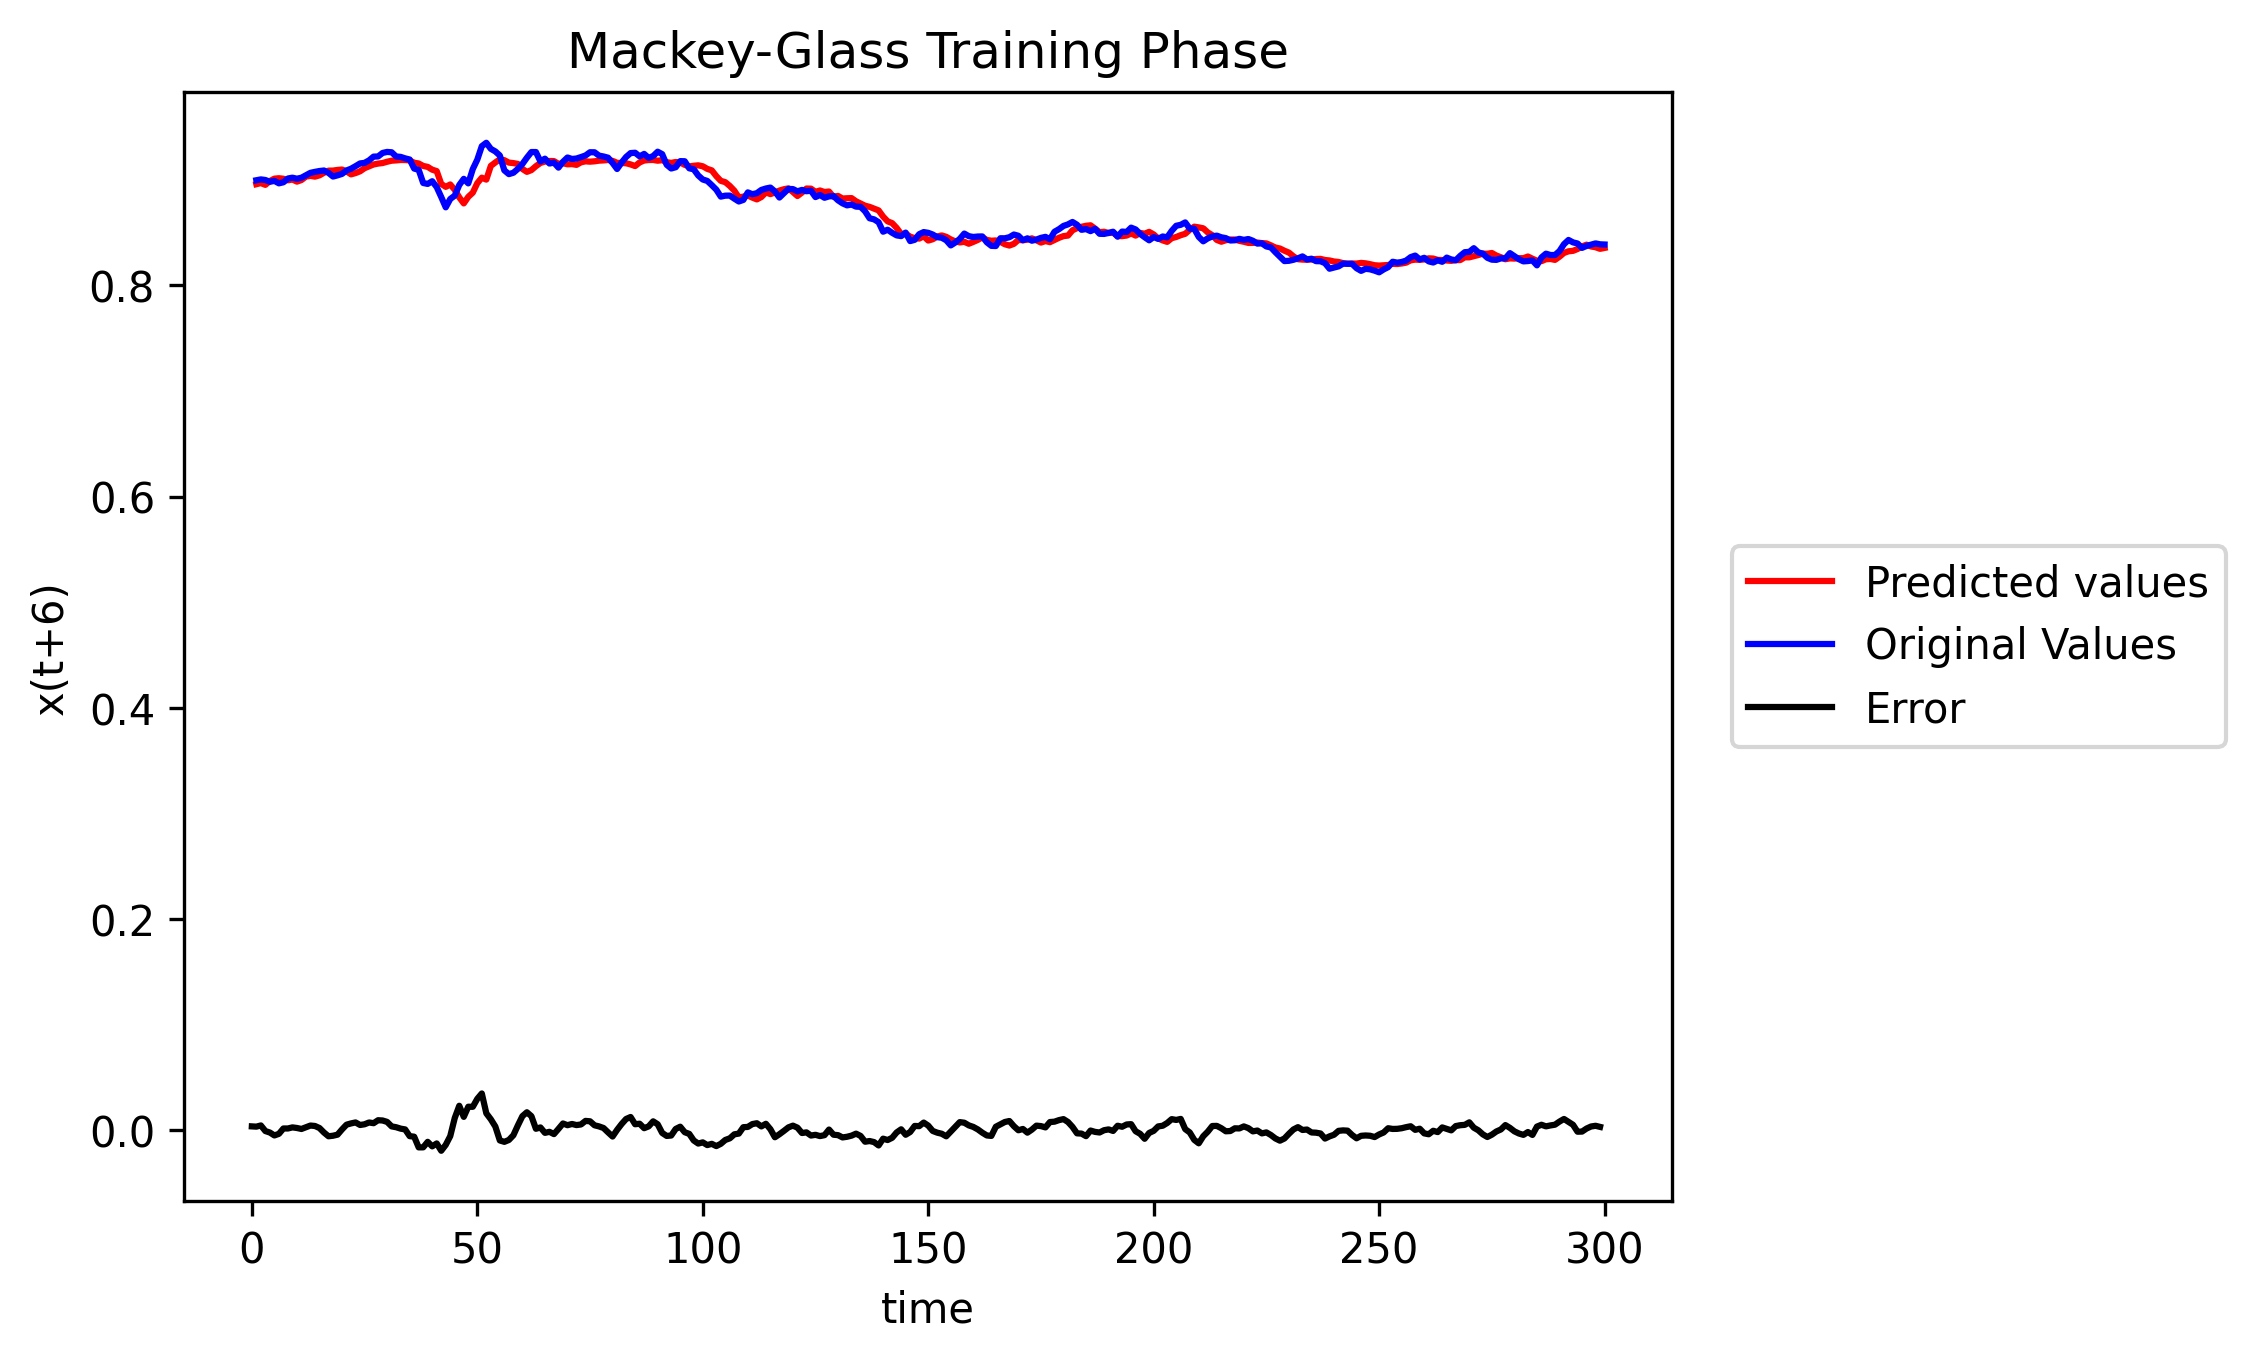

In [22]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_train+1), actual_forecasted, 'r', label='Predicted values')
plt.plot(np.arange(1,n_points_train+1), actual_targets,'b', label='Original Values')
plt.plot(error, 'k',label='Error')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Training Phase')
plt.show()

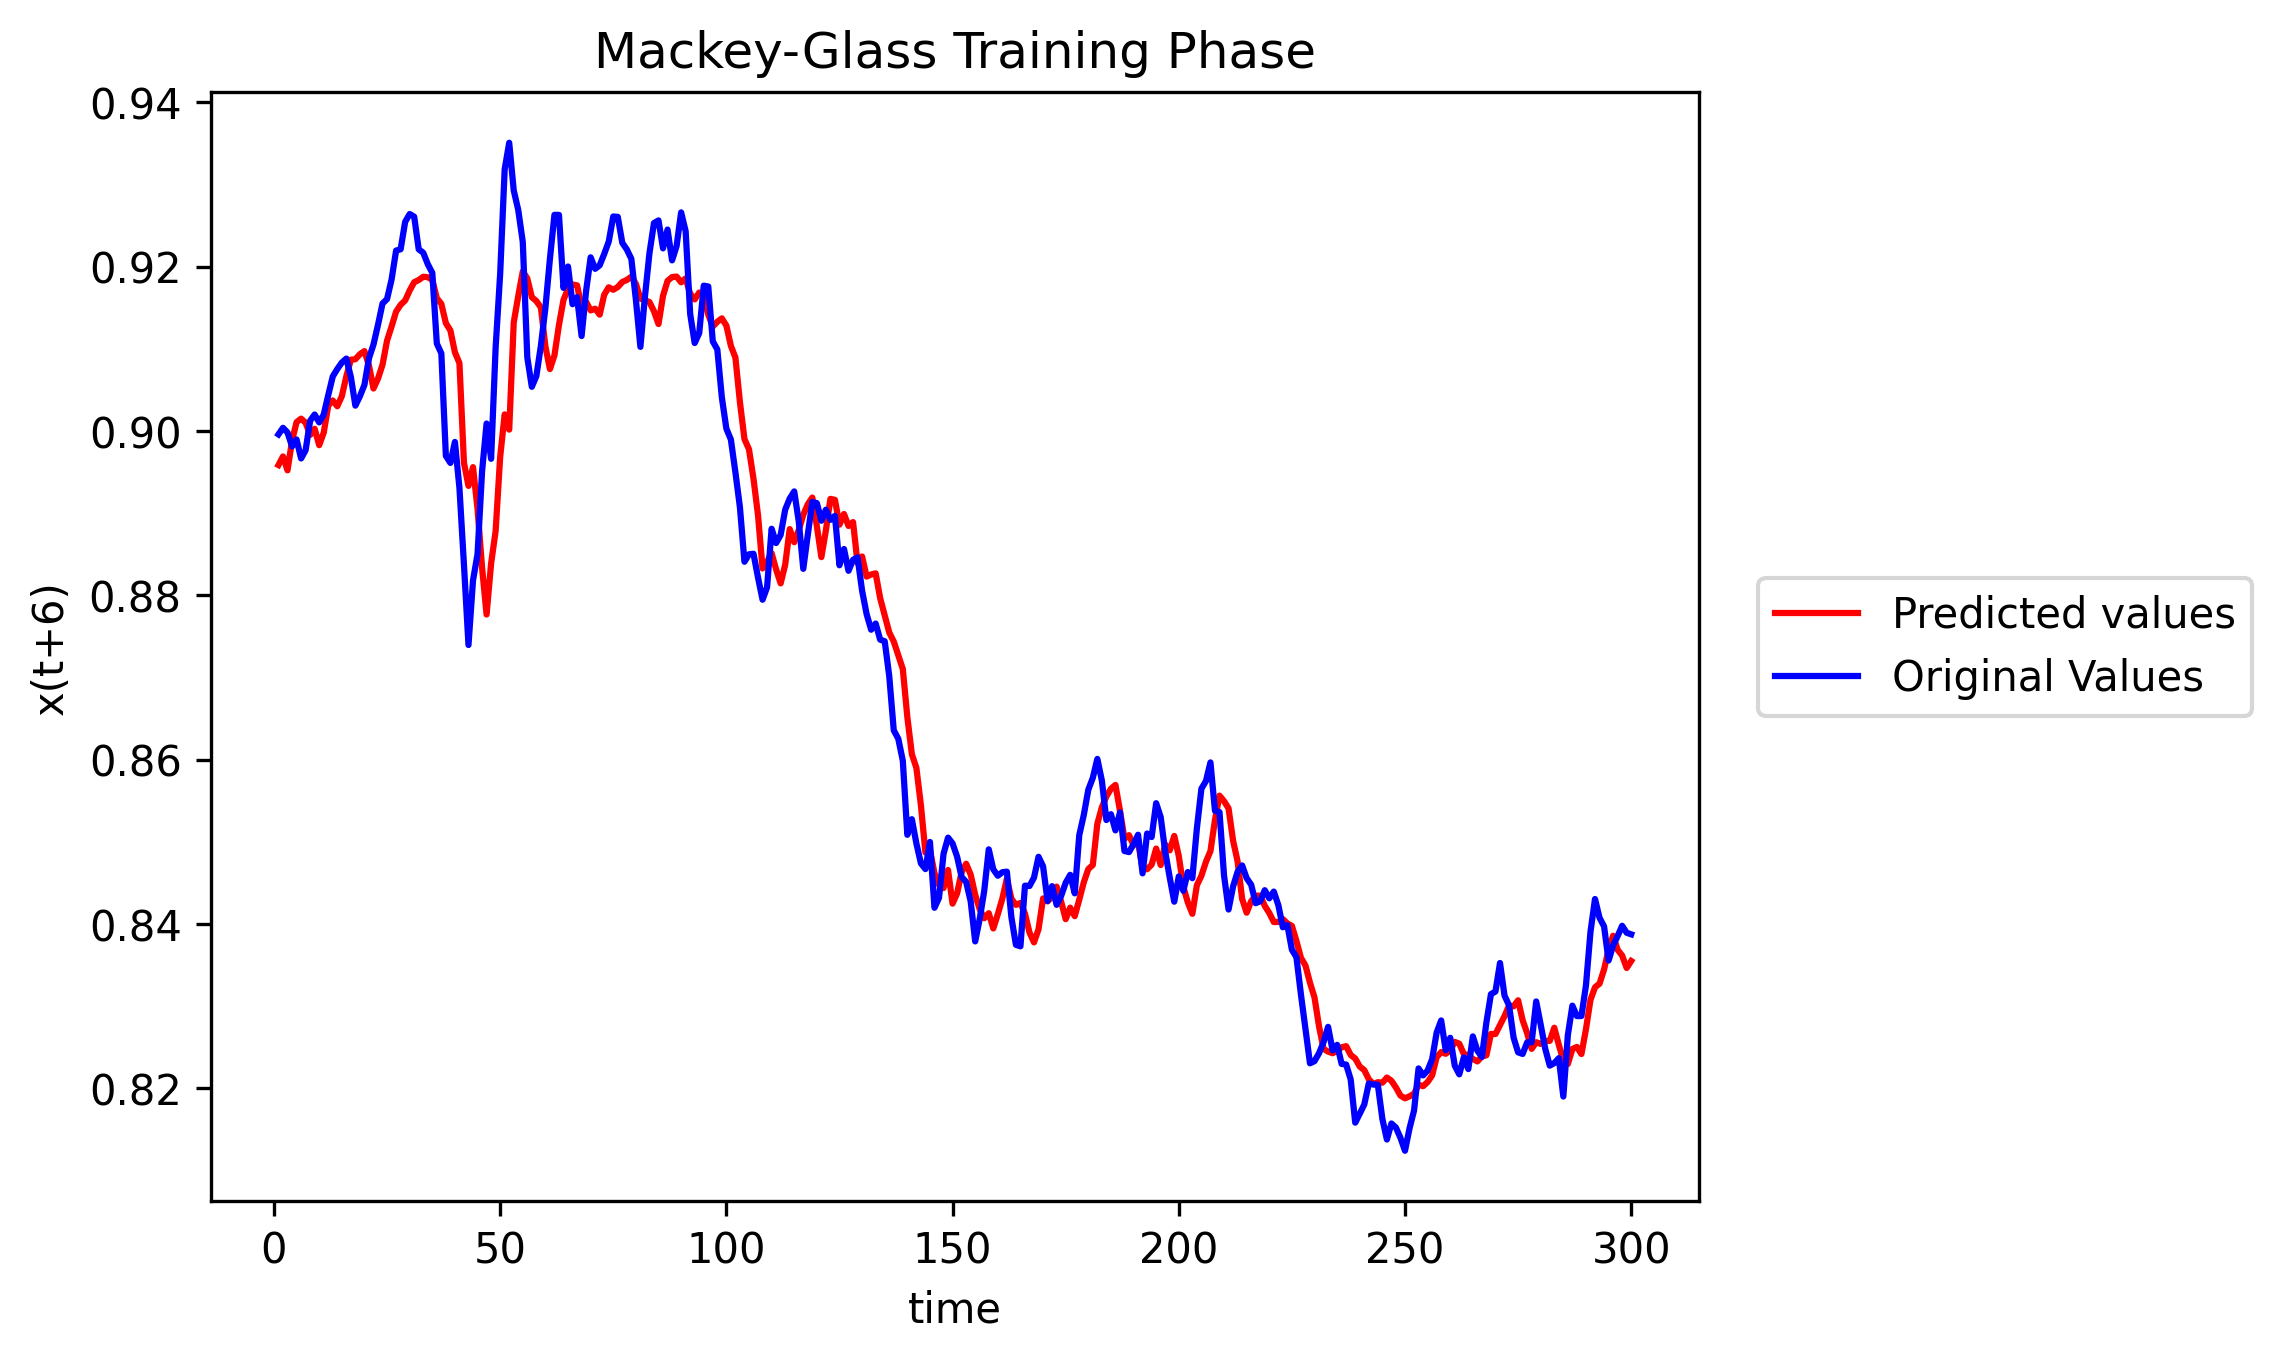

In [23]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_train+1), actual_forecasted, 'r', label='Predicted values')
plt.plot(np.arange(1,n_points_train+1), actual_targets,'b', label='Original Values')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Training Phase')
plt.show()

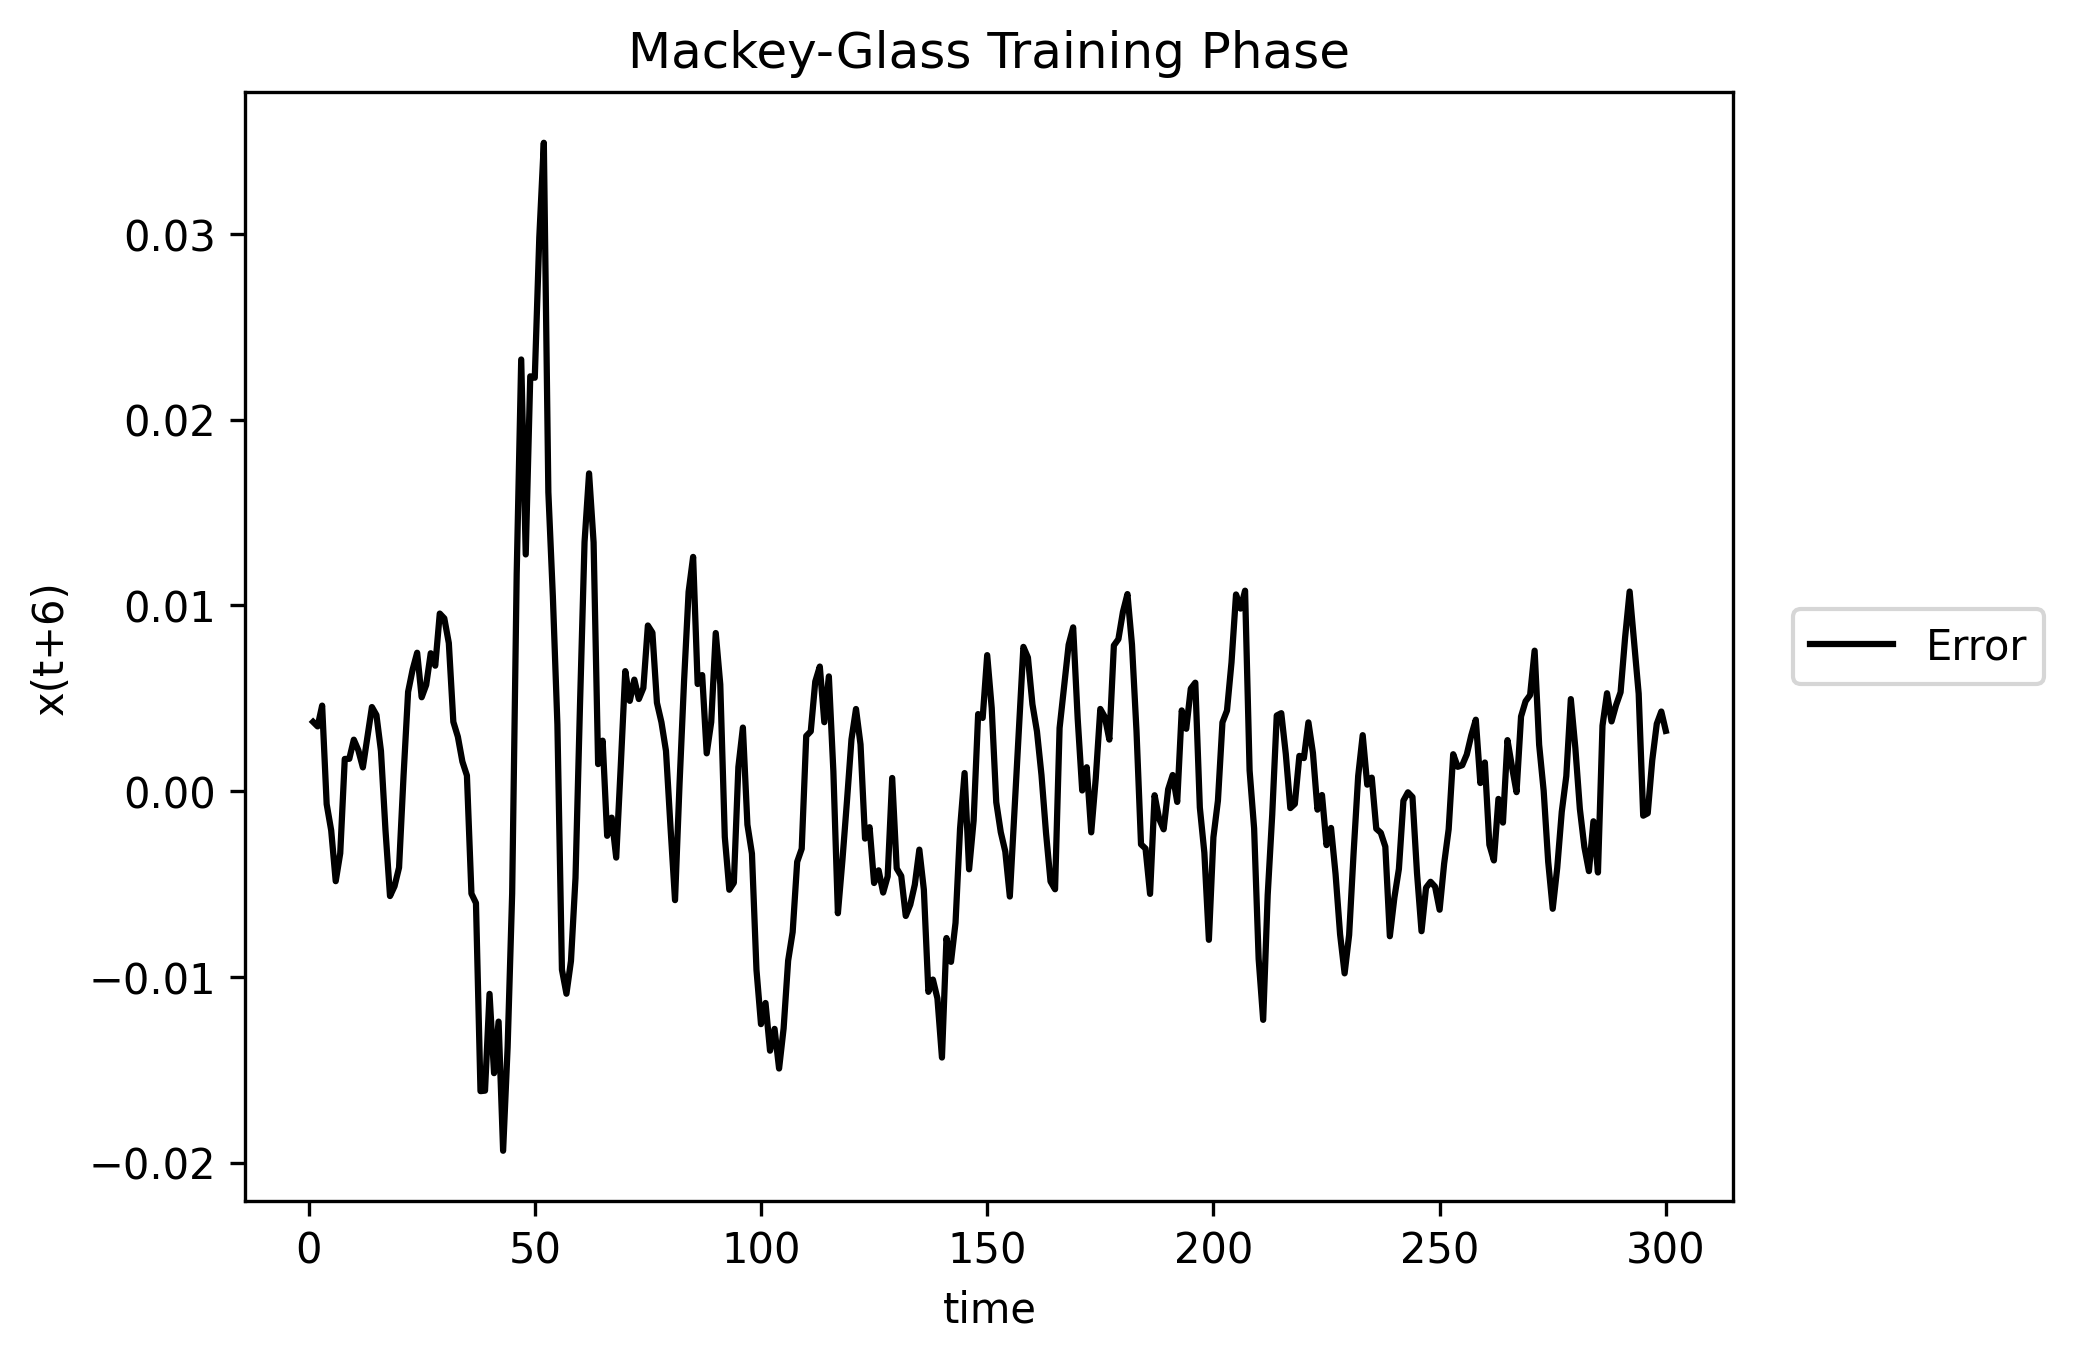

In [24]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_train+1), error, 'k',label='Error')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Training Phase')
plt.show()

In [25]:
RMSE = np.sqrt(np.sum(np.square(actual_forecasted-actual_targets))/n_points_train)
print(RMSE)

0.007022038444575662


In [26]:
# Calculate the forecasted values for the testing phase.
n_points_test = 76
forecasted = np.zeros((n_points_test))
for k in range(n_points_test):
  forecasted[k] = net(X_test[k].type(torch.float))

In [27]:
actual_forecasted = scaler.inverse_transform(forecasted.reshape(-1, 1))
actual_targets = scaler.inverse_transform(scaled_data_test[:,4].reshape(-1, 1))
error = actual_targets - actual_forecasted

In [28]:
torch.save(actual_forecasted, 'actual_forecasted_qcnn_mg_test.pt')
torch.save(actual_targets, 'actual_targets_qcnn_mg_test.pt')

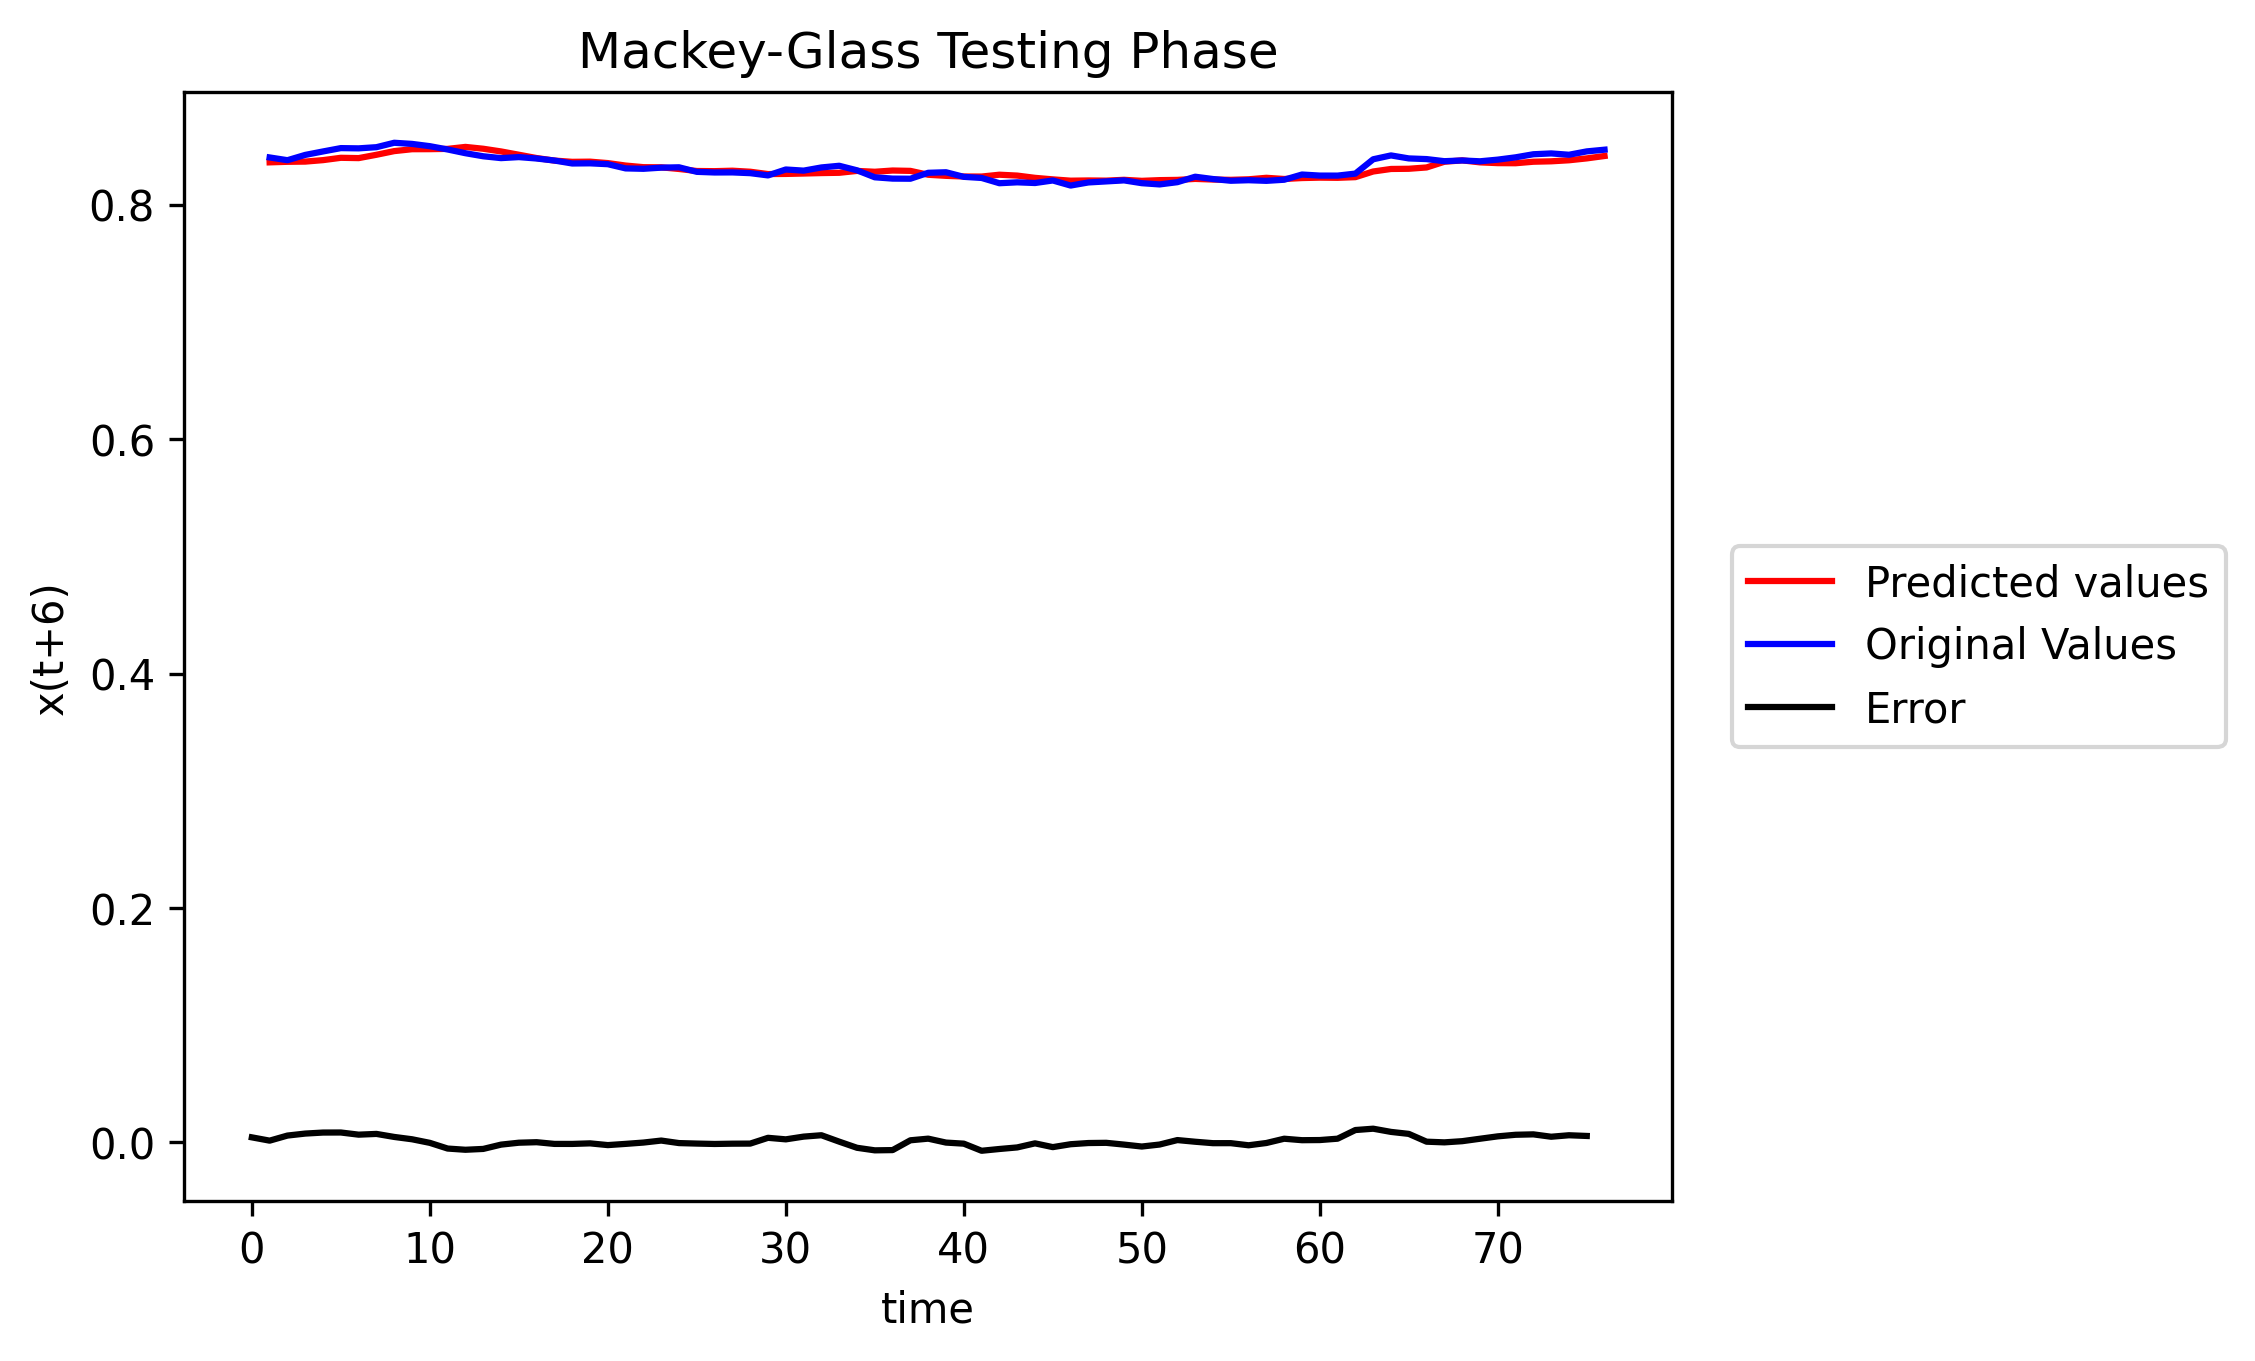

In [29]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_test+1), actual_forecasted, 'r', label='Predicted values')
plt.plot(np.arange(1,n_points_test+1), actual_targets,'b', label='Original Values')
plt.plot(error, 'k',label='Error')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Testing Phase')
plt.show()

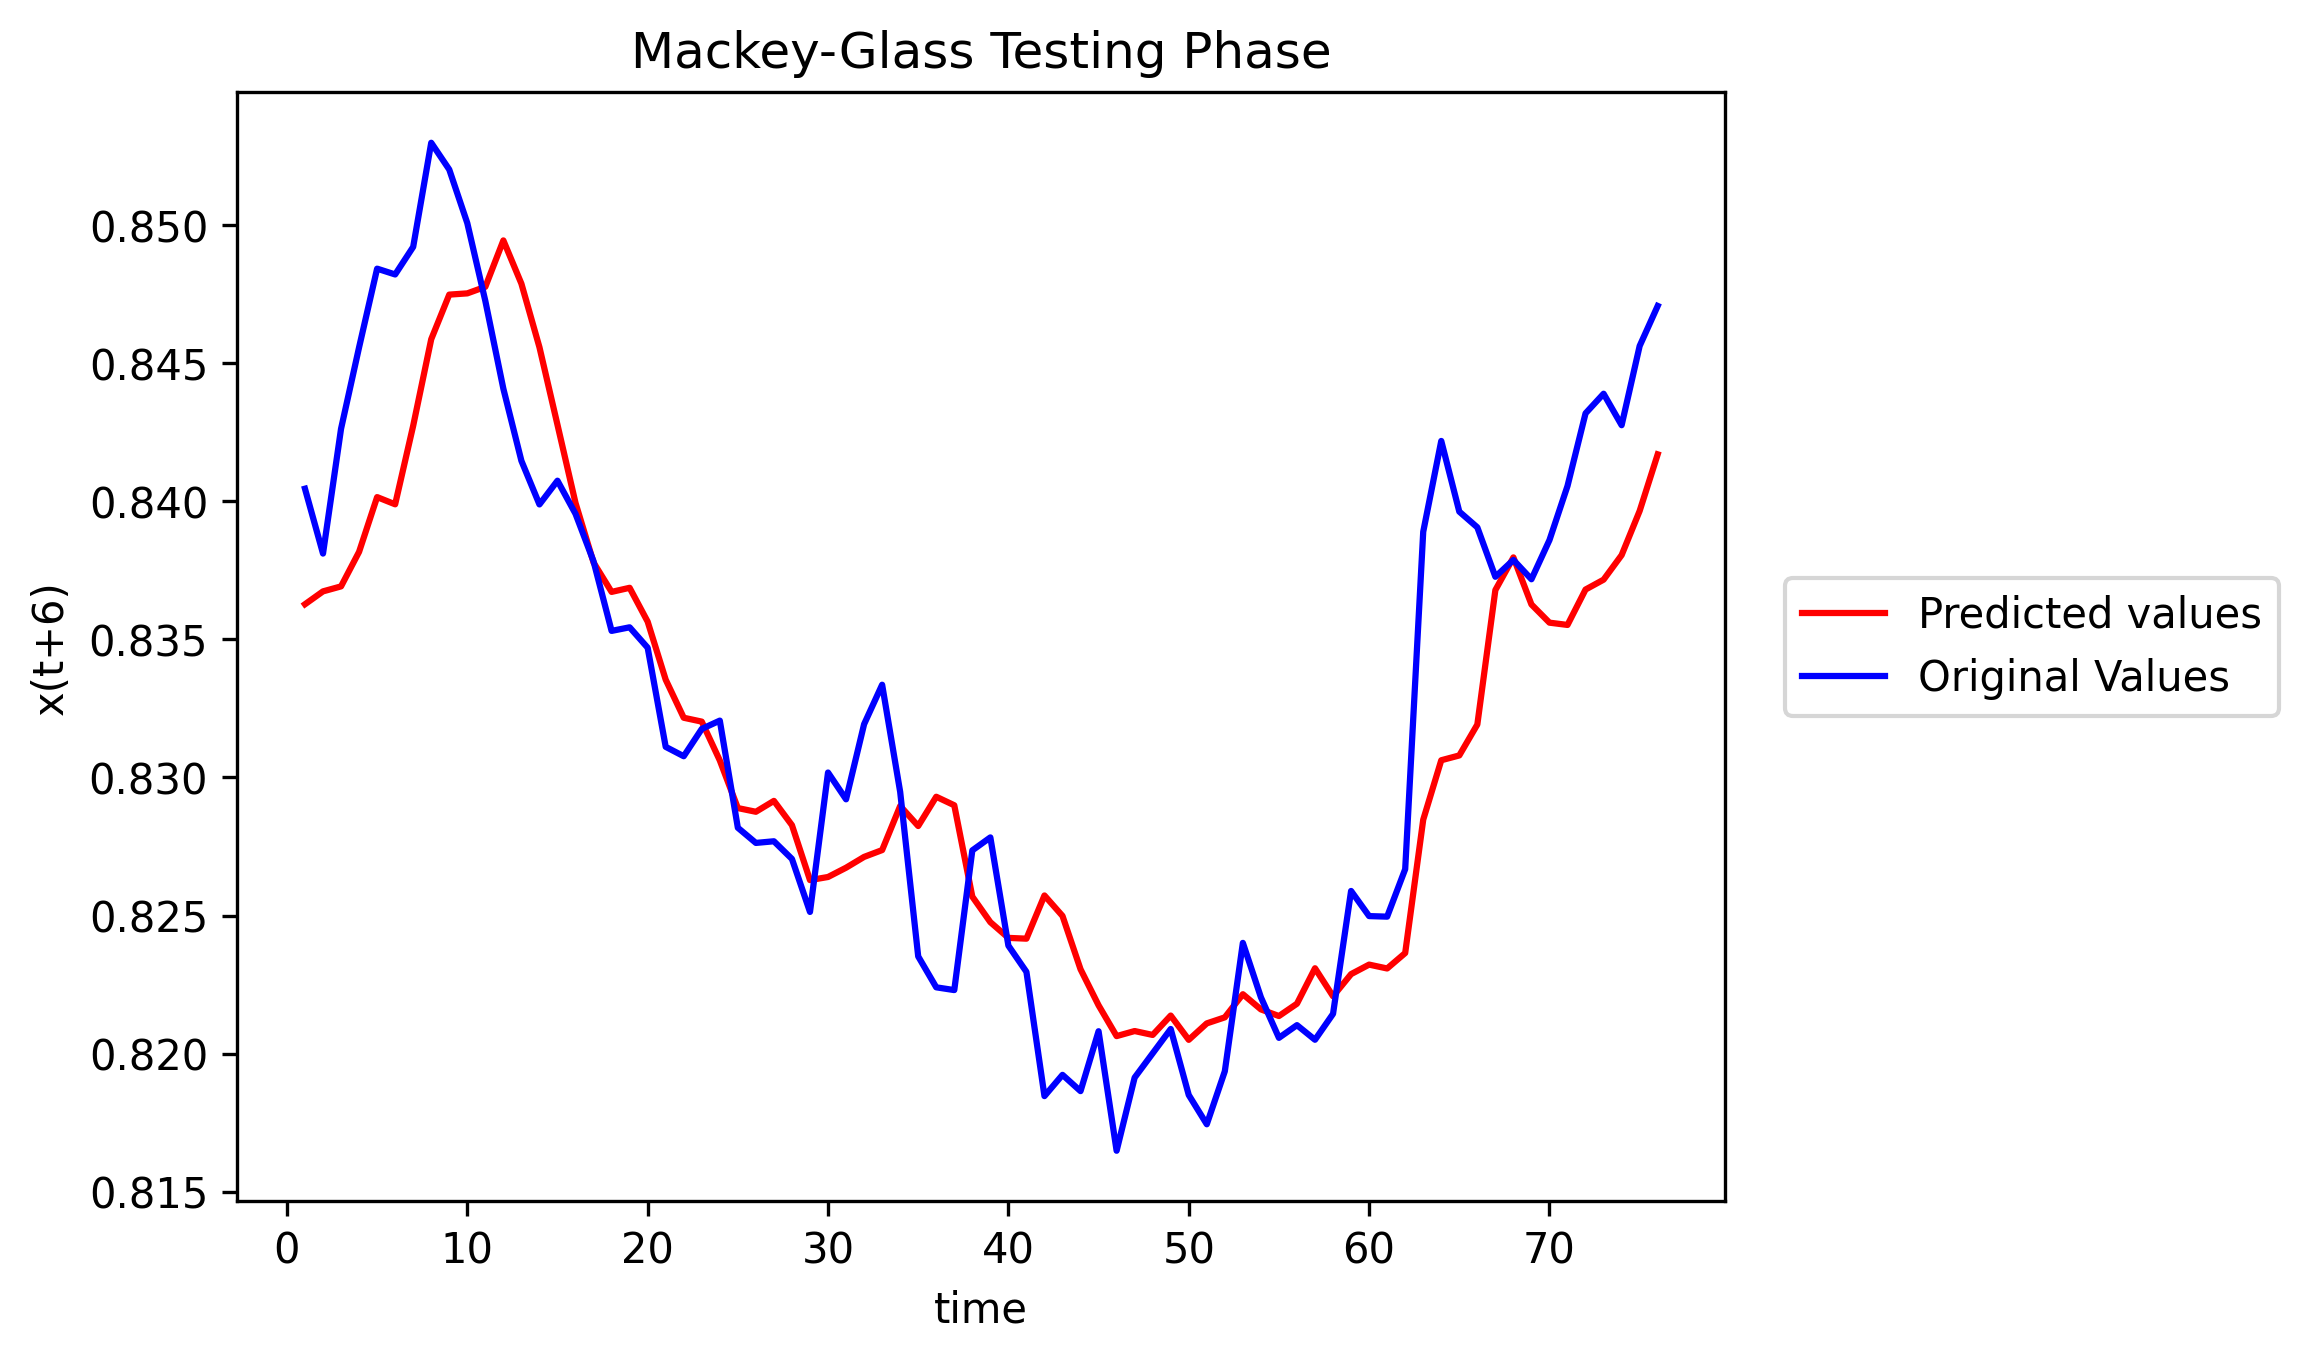

In [30]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_test+1), actual_forecasted, 'r', label='Predicted values')
plt.plot(np.arange(1,n_points_test+1), actual_targets,'b', label='Original Values')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Testing Phase')
plt.show()

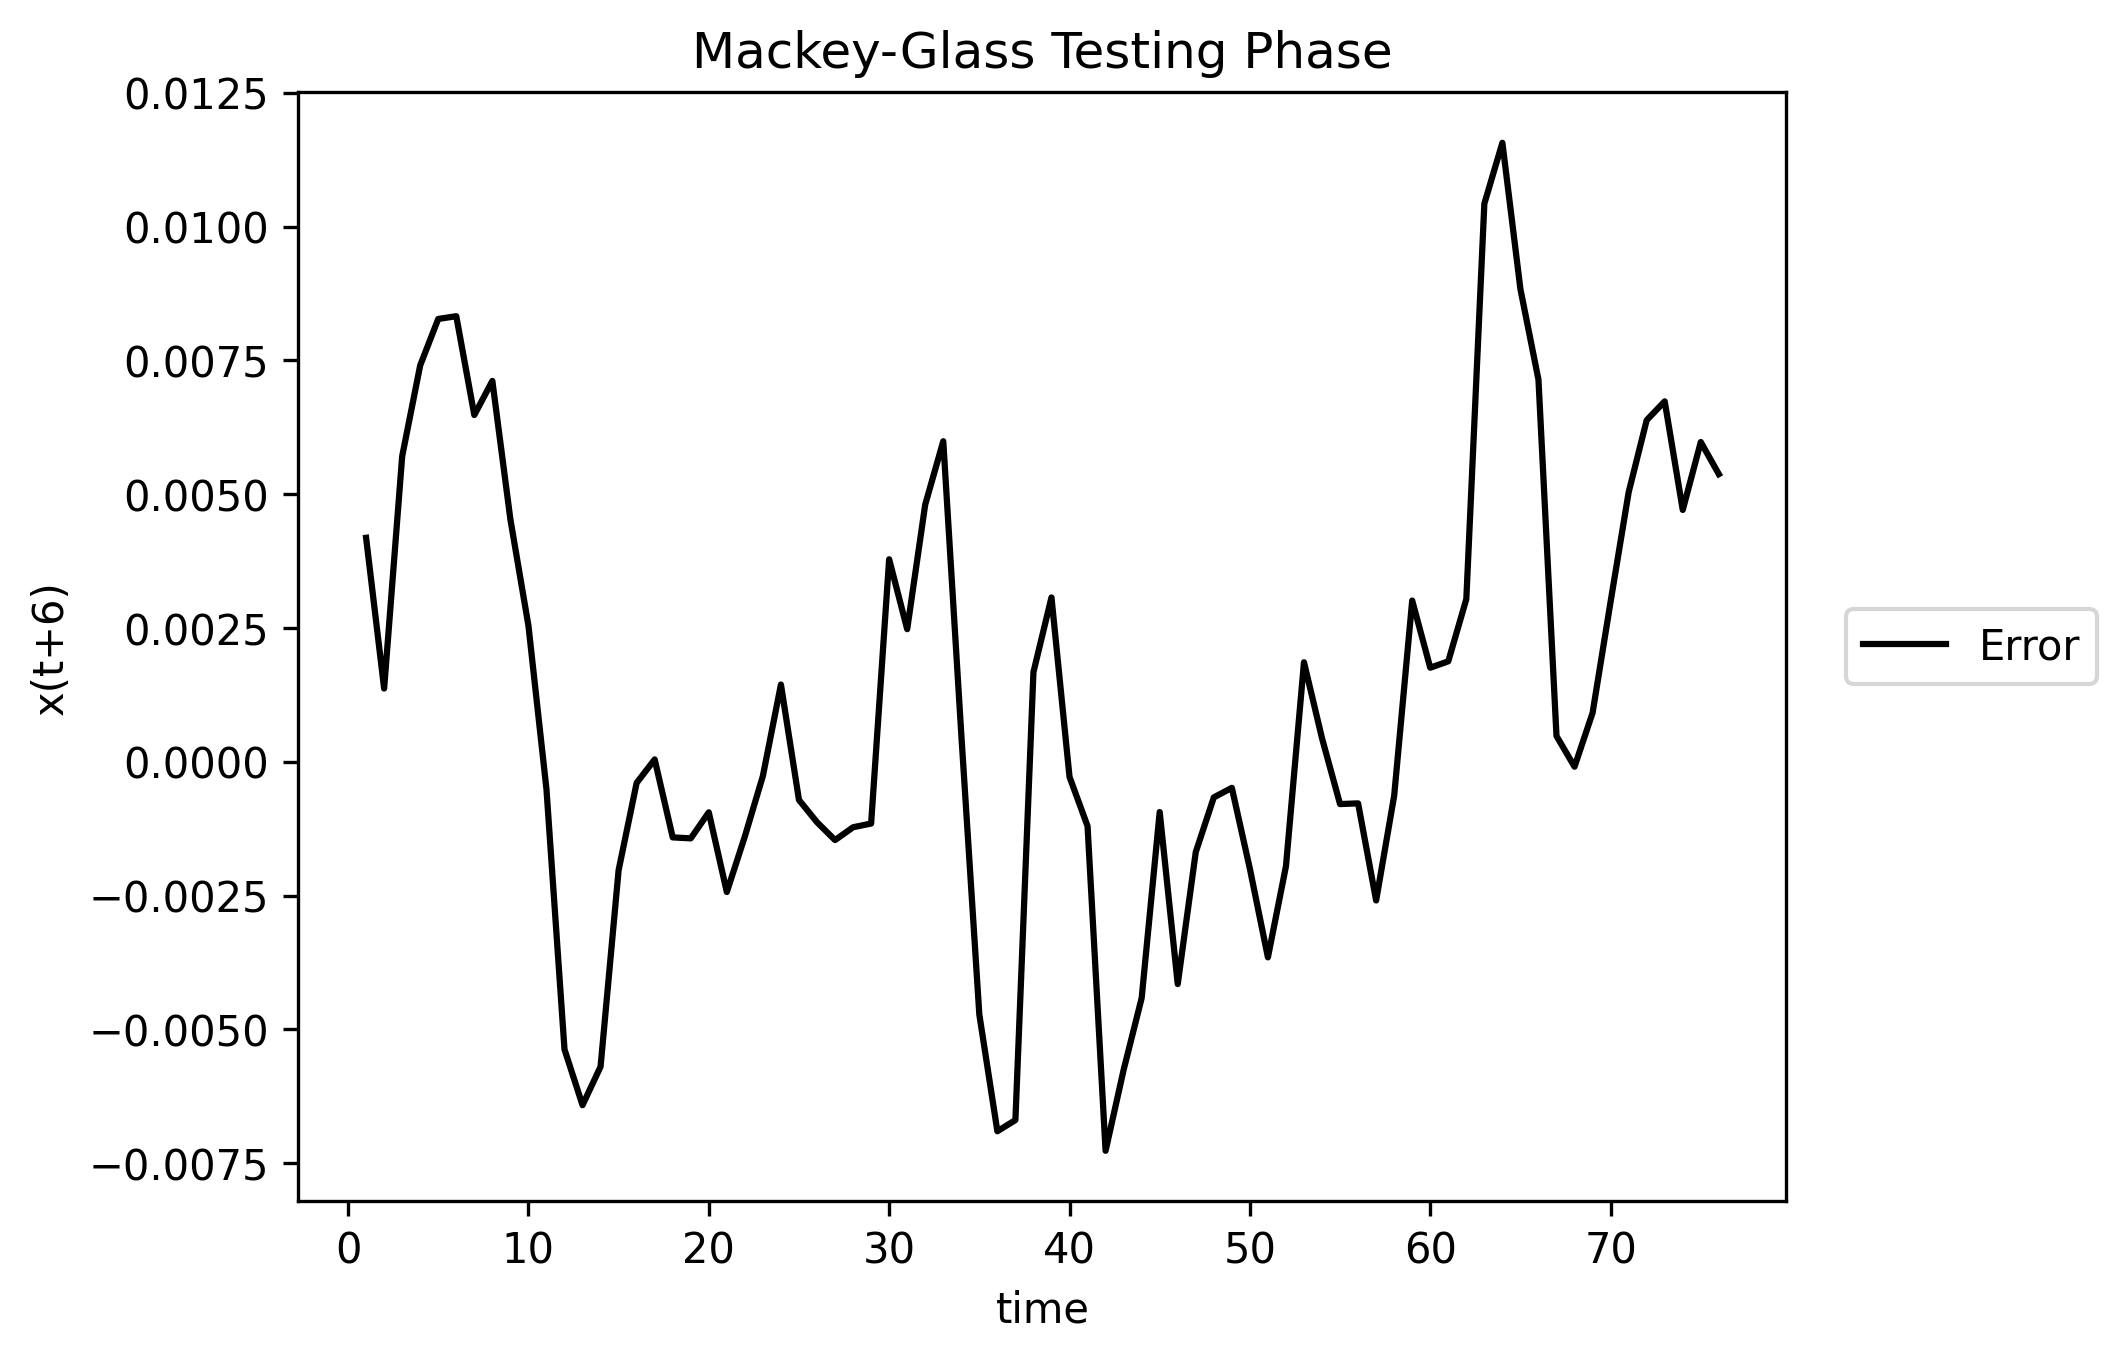

In [31]:
plt.figure(dpi=300)
plt.plot(np.arange(1,n_points_test+1), error, 'k',label='Error')
plt.ylabel('x(t+6)')
plt.xlabel('time')
plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left", borderaxespad=0)
plt.title('Mackey-Glass Testing Phase')
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error
RMSE = np.sqrt(np.sum(np.square(actual_forecasted-actual_targets))/n_points_test)
print('RMSE=',RMSE)
mae = mean_absolute_error(actual_forecasted,actual_targets)
print("MAE=",mae)

MAPE = np.sum(np.absolute(actual_forecasted-actual_targets)/np.absolute(actual_targets))/n_points_test
print("MAPE=",MAPE)


RMSE= 0.0043918131020018875
MAE= 0.003419908163676912
MAPE= 0.004092125788448008
